In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('train.csv')
df.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [4]:
df.isnull().mean()*100

id                  0.0
age                 0.0
gender              0.0
course              0.0
study_hours         0.0
class_attendance    0.0
internet_access     0.0
sleep_hours         0.0
sleep_quality       0.0
study_method        0.0
facility_rating     0.0
exam_difficulty     0.0
exam_score          0.0
dtype: float64

In [5]:
df.shape

(630000, 13)

In [6]:
df.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [7]:
cat_features=df.select_dtypes(exclude='number').columns
num_features=df.select_dtypes(include='number').columns

<Axes: >

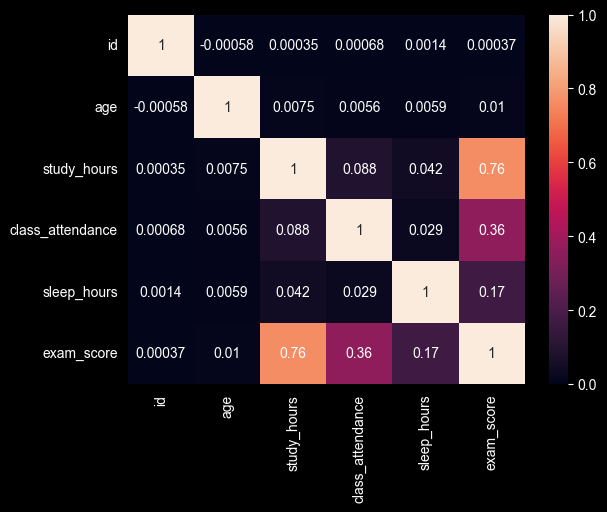

In [8]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

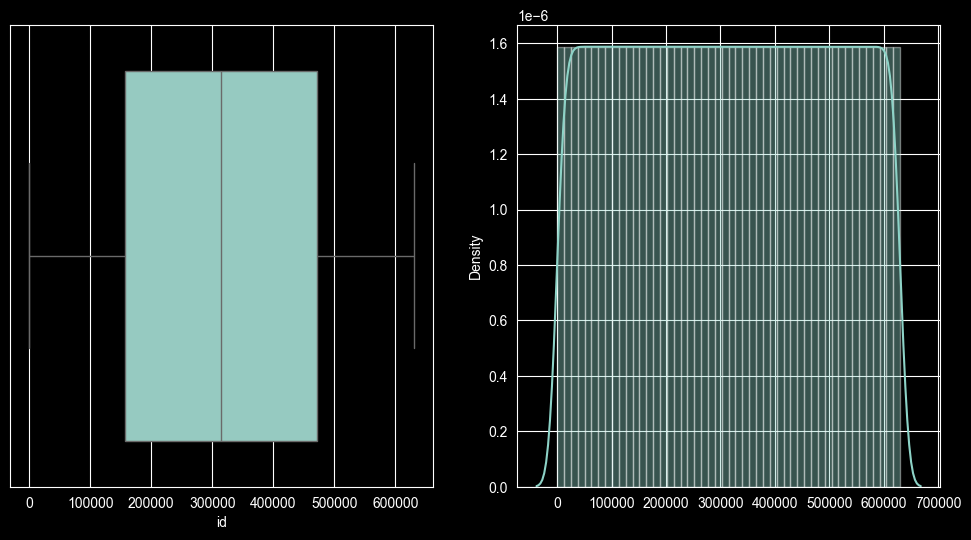

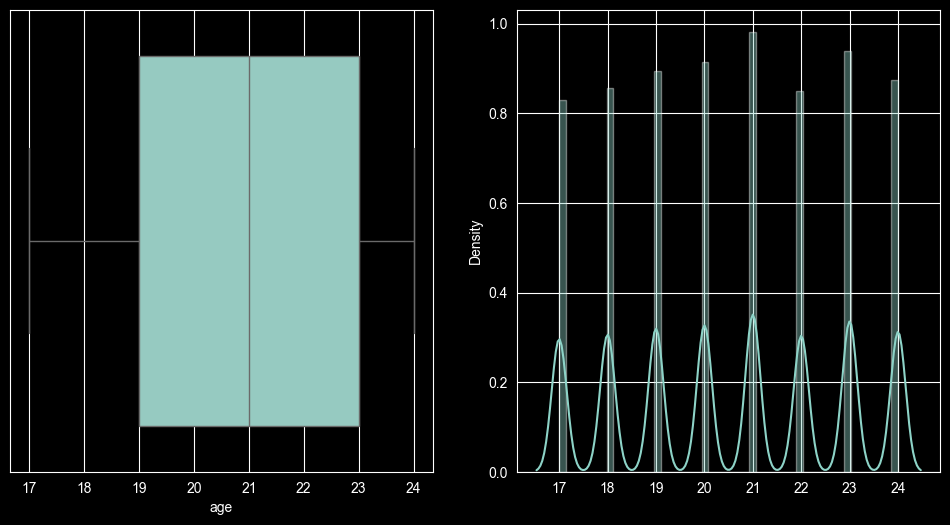

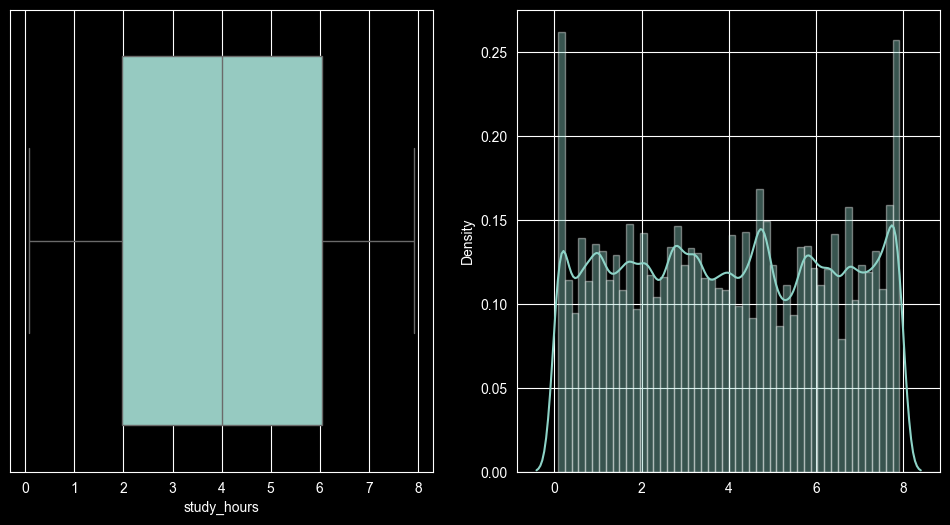

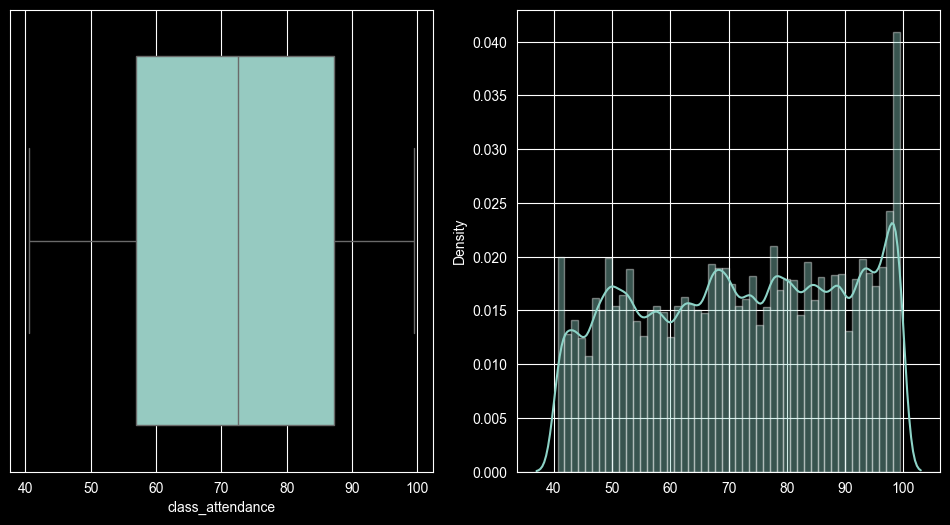

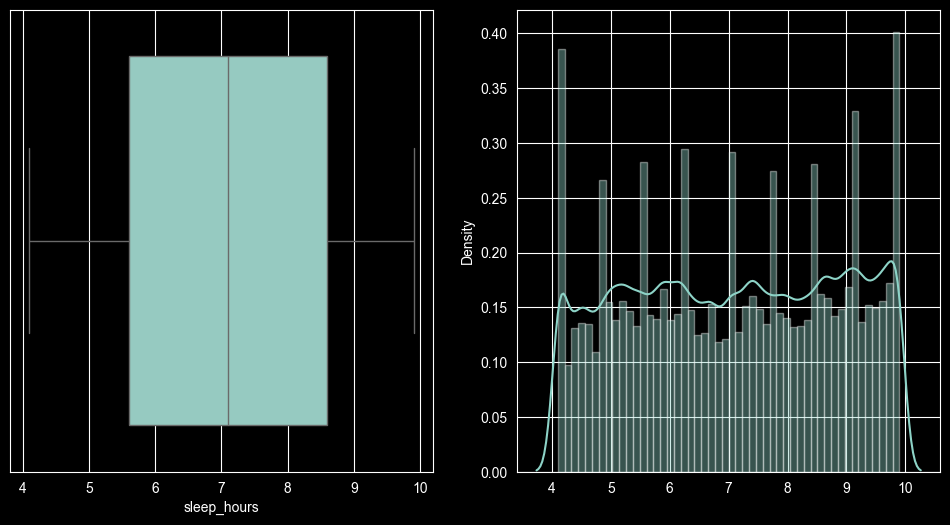

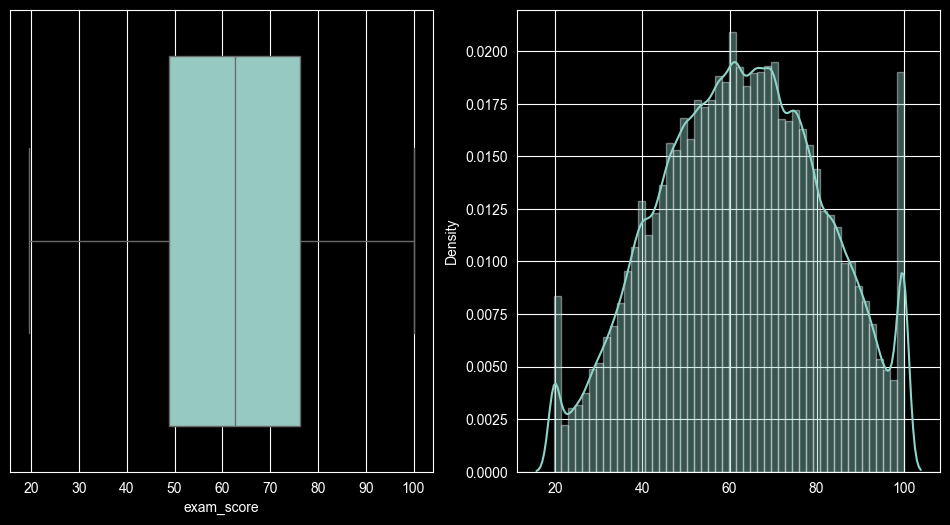

In [9]:
for col in num_features:
    plt.figure(figsize=(12,6))
    plt.subplot(121)
    sns.boxplot(x=df[col])
    plt.subplot(122)
    sns.distplot(x=df[col])

In [10]:
cat_features

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

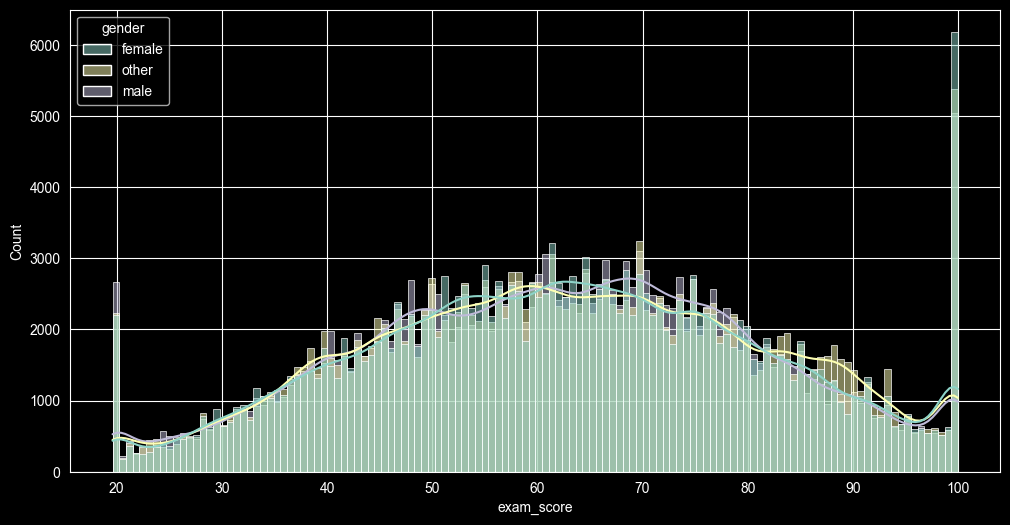

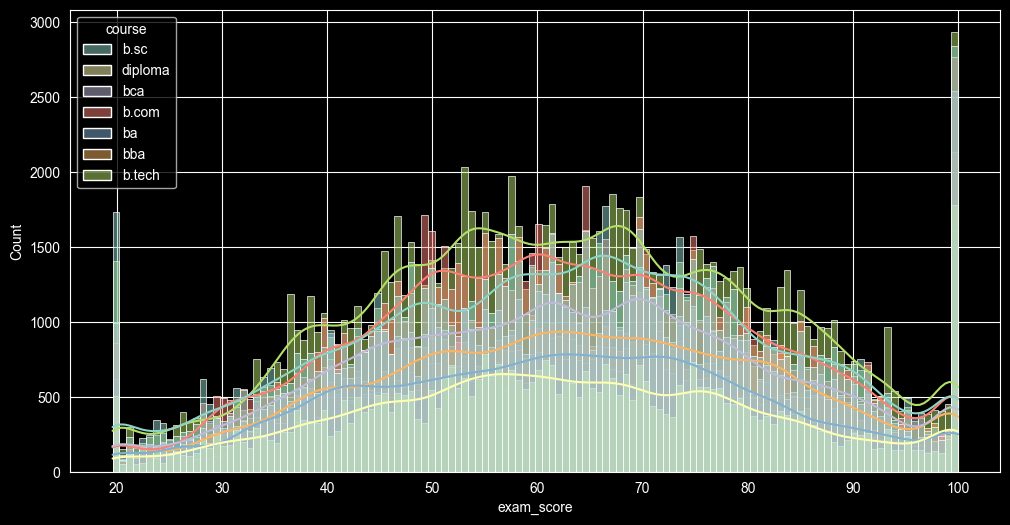

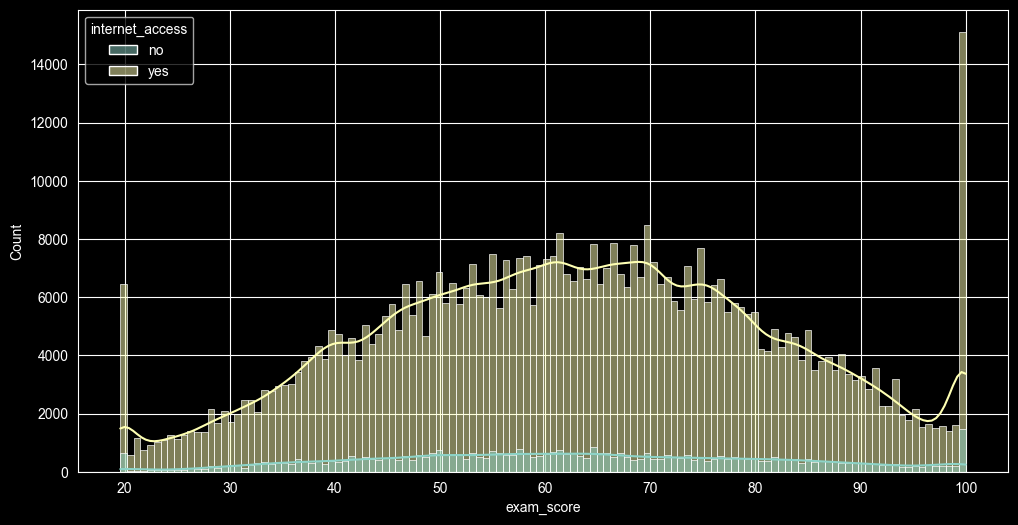

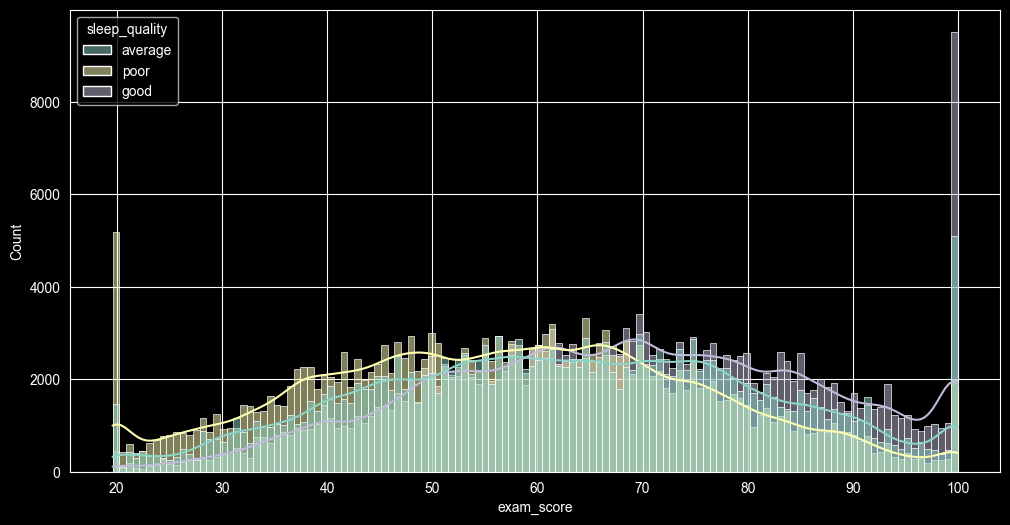

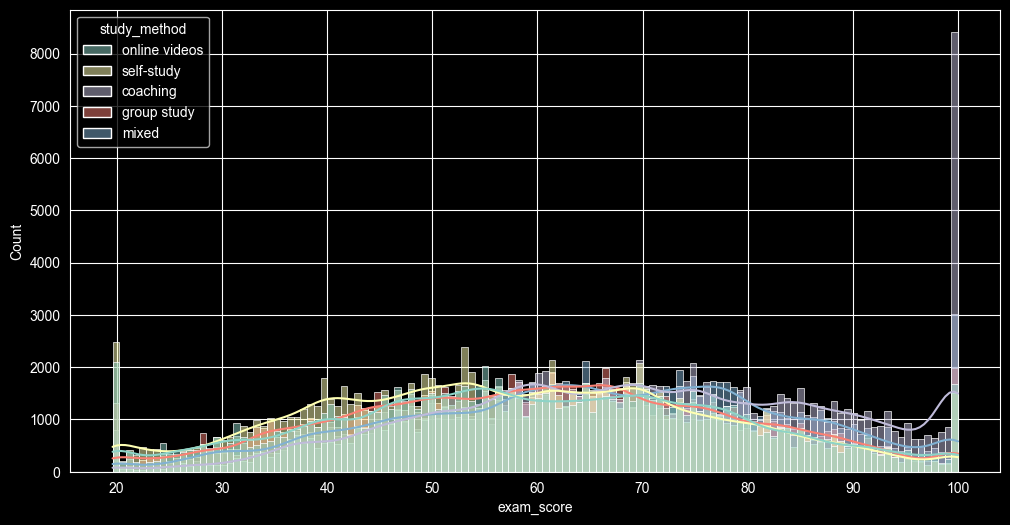

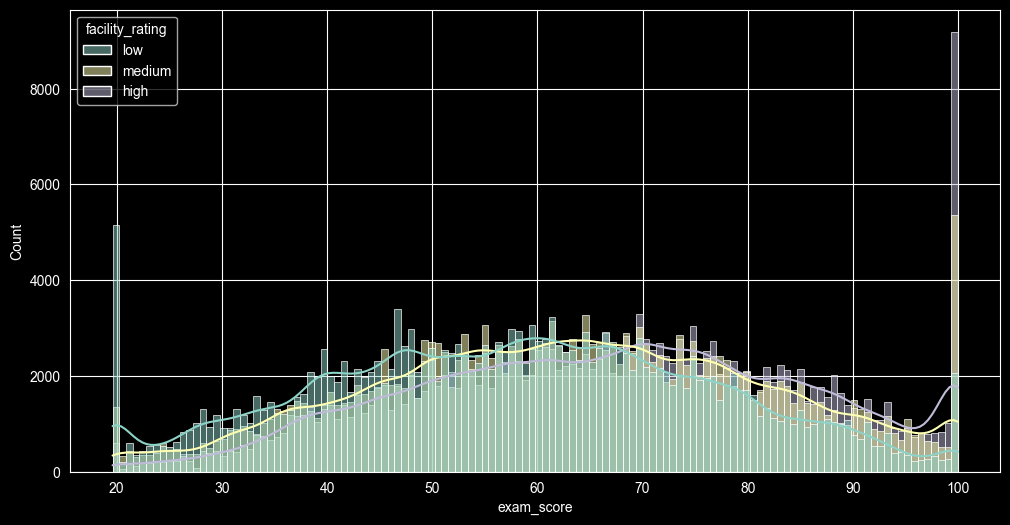

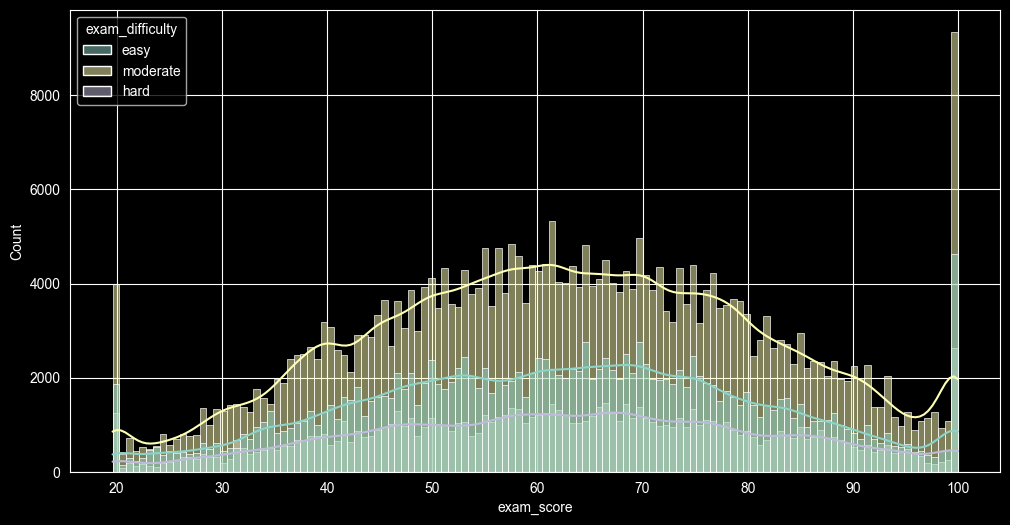

In [11]:
for col in cat_features:
    plt.figure(figsize=(12,6))
    sns.histplot(x=df['exam_score'],hue=df[col],kde=True)

In [12]:
df['internet_access'].value_counts()

internet_access
yes    579423
no      50577
Name: count, dtype: int64

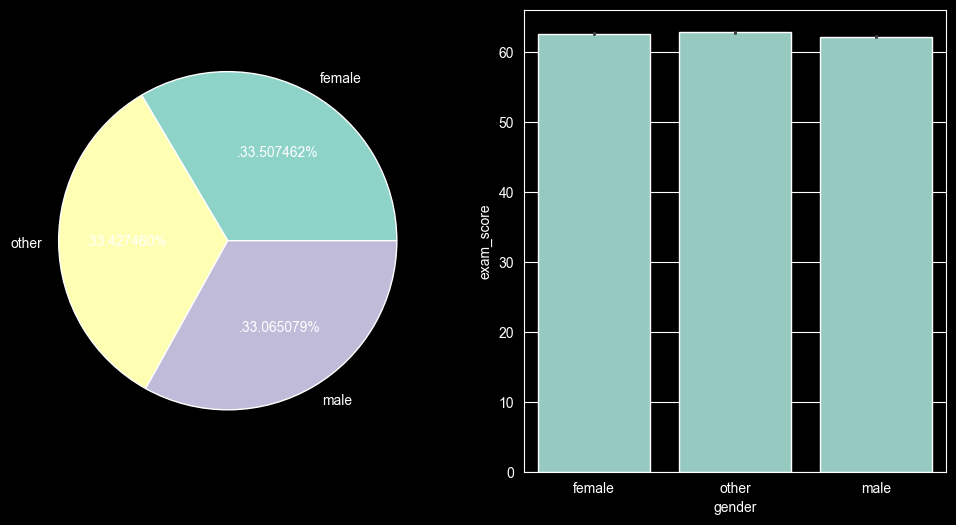

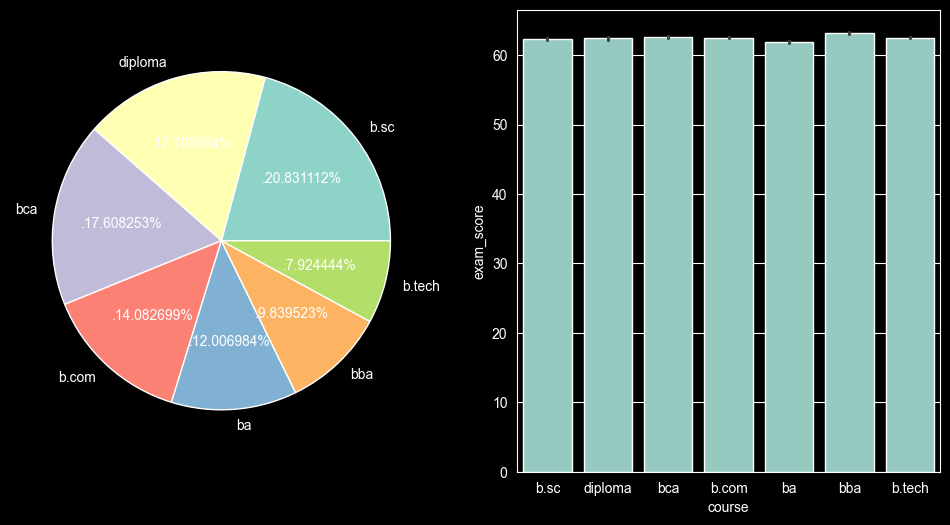

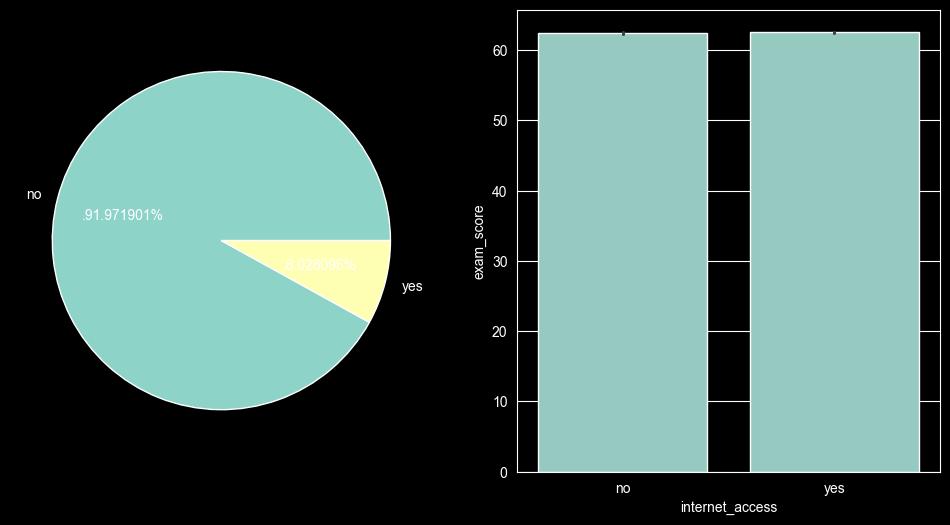

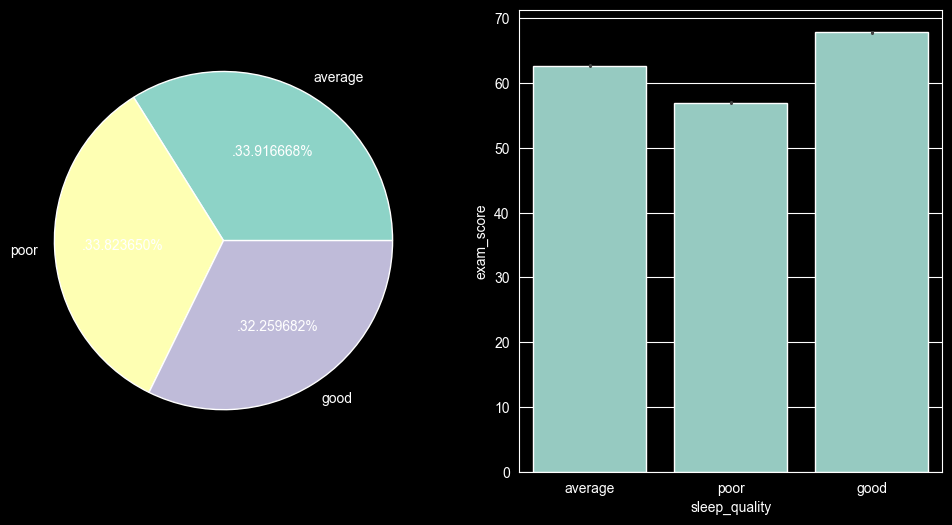

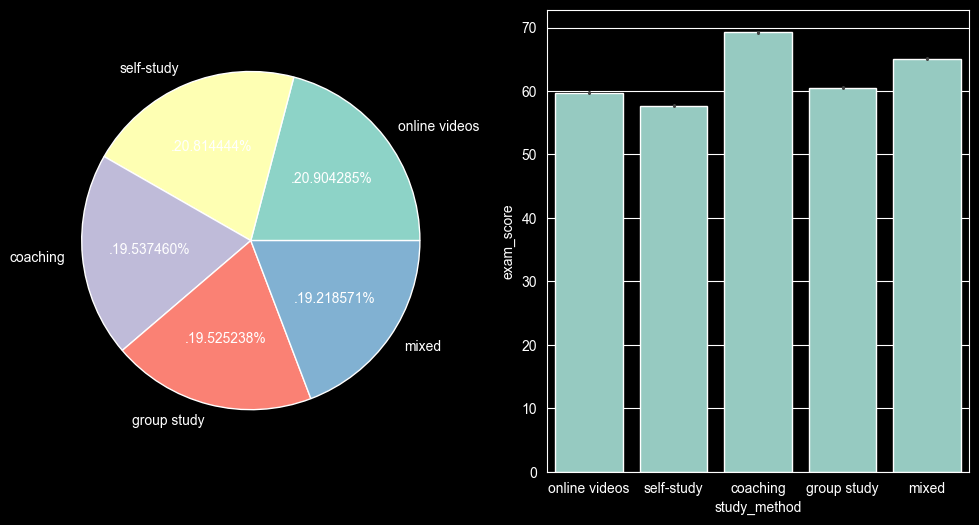

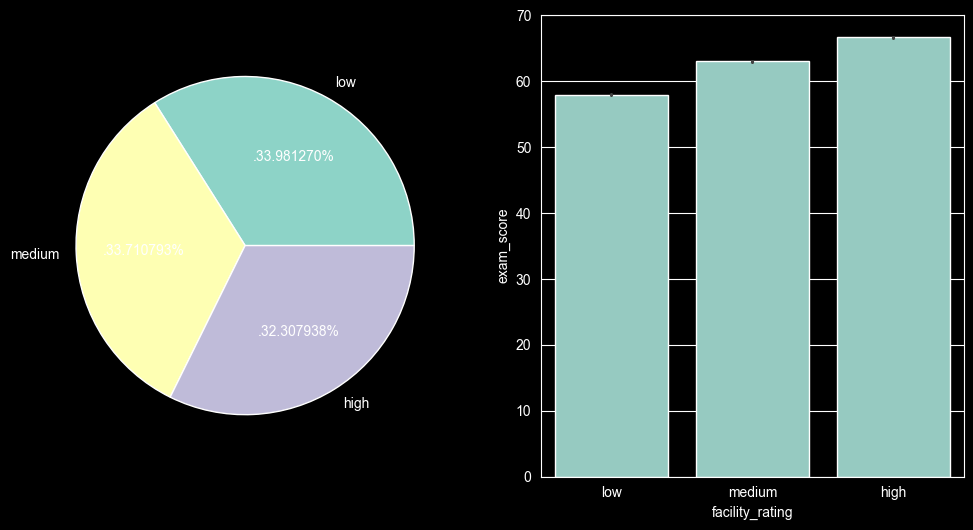

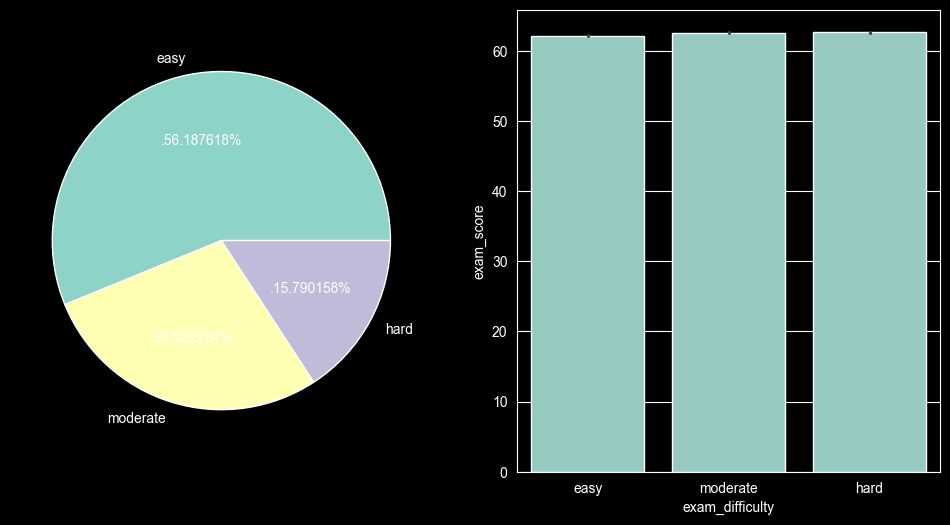

In [13]:
for col in cat_features:
    size=df[col].value_counts()
    labels=df[col].unique()
    plt.figure(figsize=(12,6))
    plt.subplot(121)
    plt.pie(size,labels=labels,autopct= '.%2f%%')
    plt.subplot(122)
    sns.barplot(x=df[col],y=df['exam_score'])


In [8]:
df.drop(columns=['id','age'],inplace=True)

In [9]:
df.drop(columns=['internet_access'],inplace=True)

In [10]:
from sklearn.model_selection import train_test_split,GridSearchCV

x = df.drop(columns=['exam_score'])
y = df['exam_score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [12]:
num_features=x.select_dtypes(include='number').columns
cat_features=x.select_dtypes(exclude='number').columns

In [13]:
cat_features

Index(['gender', 'course', 'sleep_quality', 'study_method', 'facility_rating',
       'exam_difficulty'],
      dtype='object')

In [14]:
ohe_features=['gender','course','study_method']
oe_features=['sleep_quality','facility_rating','exam_difficulty']

In [15]:
df['exam_difficulty'].unique()

array(['easy', 'moderate', 'hard'], dtype=object)

In [16]:
oe_categories=[
    ['poor','average','good'],
    ['low','medium','high'],
    ['easy','moderate','hard'],
]

num_transform=(
    'num',Pipeline([
        ('StandardScaler',StandardScaler()),
    ]),num_features
)
ohe_transform=(
    'ohe',Pipeline([
        ('encoding',OneHotEncoder(handle_unknown='ignore'))
    ]),ohe_features
)
oe_transform=(
    'oe',Pipeline([
        ('encoding',OrdinalEncoder(categories=oe_categories,handle_unknown='use_encoded_value',unknown_value=-1))
    ]),oe_features
)

In [17]:
transformer=ColumnTransformer(transformers=[num_transform,oe_transform,ohe_transform],remainder='passthrough')

In [18]:
from sklearn.metrics import root_mean_squared_error,r2_score,mean_absolute_error,mean_squared_error

In [19]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
pipe_lr=Pipeline([
    ('transformer',transformer),
    ('clf',lr)
])
pipe_lr.fit(x_train,y_train)

,steps,"[('transformer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('oe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
y_pred=pipe_lr.predict(x_test)
root_mean_squared_error(y_test,y_pred)

8.887094097041517

In [27]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.7779247204909031
7.0934906320934
78.98044148967017


In [28]:
from sklearn.tree import DecisionTreeRegressor

tree=DecisionTreeRegressor(max_depth=10,min_samples_split=4,random_state=42,)
pipe_tree=Pipeline([
    ('transformer',transformer),
    ('clf',tree)
])
pipe_tree.fit(x_train,y_train)

,steps,"[('transformer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('oe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
y_pred=pipe_tree.predict(x_test)
root_mean_squared_error(y_test,y_pred)

9.355578556346169

In [30]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.7538941370899728
7.4742505821660865
87.52685012396427


In [31]:
from sklearn.ensemble import RandomForestRegressor

clf=RandomForestRegressor()
pipe=Pipeline([
    ('transformer',transformer),
    ('clf',clf)
])
pipe.fit(x_train,y_train)

,steps,"[('transformer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('oe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
y_pred=pipe.predict(x_test)
print(root_mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

9.128091752432786
0.7657170661272358
7.255794050230158
83.32205904083145


In [20]:
from sklearn.svm import SVR

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1))
])
model.fit(x_train,y_train)

ValueError: could not convert string to float: 'other'

In [ ]:
y_pred=model.predict(x_test)
print(root_mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

In [ ]:
from sklearn.naive_bayes import Dumm

In [31]:
from xgboost import XGBRegressor

In [32]:
from sklearn.pipeline import Pipeline
xgb=XGBRegressor()
pipe=Pipeline([
    ('transformer',transformer),
    ('clf',xgb)
])

pipe.fit(x_train,y_train)

,steps,"[('transformer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('oe', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
y_pred=pipe.predict(x_test)
root_mean_squared_error(y_test,y_pred)

8.796024319640367

In [34]:
test=pd.read_csv('test.csv')
test.drop(columns=['id'],inplace=True)

In [35]:
y_test_sub=pd.read_csv('sample_submission.csv')
test_preds = pipe.predict(test)
submission = y_test_sub.copy()
submission['exam_score'] = test_preds
submission.to_csv('final_submission.csv', index=False)
print("Successfull!")

Successfull!


In [36]:
# # learn curve plotting
# train_sizes = np.linspace(0.1, 1.0, 10)
# train_scores = []
# test_scores = []
# for train_size in train_sizes:
#     x_train_subset = x_train[:int(len(x_train) * train_size)]
#     y_train_subset = y_train[:int(len(y_train) * train_size)]
#
#     pipe_lr.fit(x_train_subset, y_train_subset)
#
#     y_train_pred = pipe_lr.predict(x_train_subset)
#     y_test_pred = pipe_lr.predict(x_test)
#
#     train_scores.append(mean_squared_error(y_train_subset, y_train_pred))
#     test_scores.append(mean_squared_error(y_test, y_test_pred))
# plt.figure(figsize=(10,6))
# plt.plot(train_sizes, train_scores, label='Training MSE')
# plt.plot(train_sizes, test_scores, label='Testing MSE')
# plt.xlabel('Training Set Size')
# plt.ylabel('Mean Squared Error')
# plt.title('Learning Curve')
# plt.legend()
# plt.show()

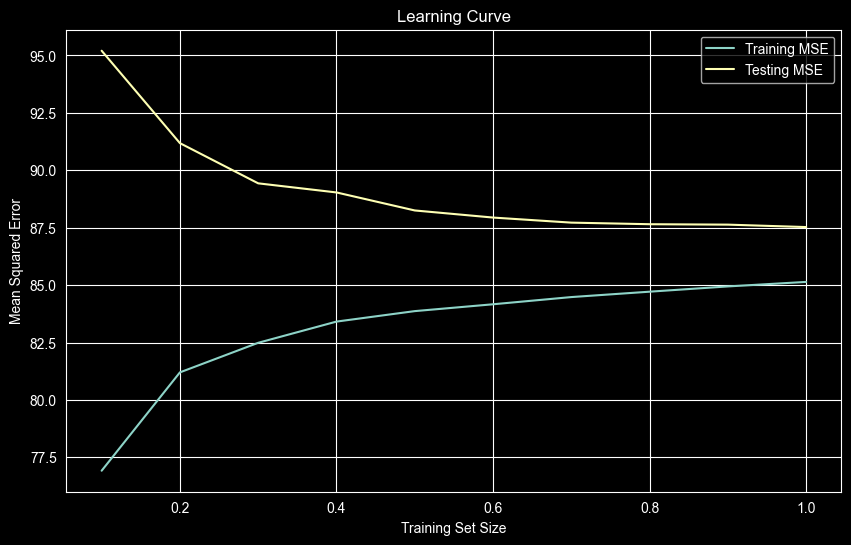

In [37]:
# learn curve plotting
import numpy as np
train_sizes = np.linspace(0.1, 1.0, 10)
train_scores = []
test_scores = []
for train_size in train_sizes:
    x_train_subset = x_train[:int(len(x_train) * train_size)]
    y_train_subset = y_train[:int(len(y_train) * train_size)]

    pipe_tree.fit(x_train_subset, y_train_subset)

    y_train_pred = pipe_tree.predict(x_train_subset)
    y_test_pred = pipe_tree.predict(x_test)

    train_scores.append(mean_squared_error(y_train_subset, y_train_pred))
    test_scores.append(mean_squared_error(y_test, y_test_pred))
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_scores, label='Training MSE')
plt.plot(train_sizes, test_scores, label='Testing MSE')
plt.xlabel('Training Set Size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [38]:
# from sklearn.model_selection import GridSearchCV
#
# clf=DecisionTreeRegressor()
# params={
#     "clf_max_depth": [4,6],
#     "clf_min_samples_split": [5, 10, 20],
#     "clf_min_samples_leaf": [2, 5, 10],
#     "clf_max_features": [None, "sqrt", "log2"]
# }
# pipe=Pipeline([
#     ('transformer',transformer),
#     ('clf',clf)
# ])
# grid=GridSearchCV(estimator=pipe,param_grid=params,cv=3,n_jobs=-1)